# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [31]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [32]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [33]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)


- Ý nghĩa dữ liệu: Mỗi dòng đại diện cho tổng mức chi tiêu hằng năm của một khách hàng đối với nhà phân phối
- Feature có ý nghĩa trực tiếp cho bài toán segmentation là các nhóm chi tiêu cốt lõi: Fresh, Milk, Grocery, Frozen, Detergents_Paper, và Delicassen
- Đánh giá chất lượng dữ liệu: Dữ liệu hoàn chỉnh (không có missing values) và đúng kiểu số. Tuy nhiên, điểm đáng lưu ý nhất là sự xuất hiện của các outliers và độ lệch phải mạnh. Khoảng cách giữa mức trung vị (50%) và giá trị lớn nhất ở tất cả các cột là cực kỳ lớn (ví dụ: ở Fresh, trung vị khoảng 8.5k nhưng max lên tới hơn 112k)
- Vai trò của Channel/Region: Hai cột này là biến phân loại, nếu đưa vào input clustering ban đầu sẽ làm nhiễu các thuật toán tính khoảng cách. Chúng sẽ được dùng ở giai đoạn profiling như một lớp ngữ cảnh để kiểm tra xem một cụm chi tiêu cụ thể thường tập trung ở kênh hay vùng nào.
- Hữu ích trong buisness context: Một kết quả phân cụm chỉ với dữ liệu chi tiêu được xem là hữu ích khi nó cô lập được các tập khách hàng có hành vi mua sắm khác biệt rõ nét. Điều này cho phép nhà phân phối đề xuất hành động cụ thể

In [34]:
missing_and_dupes = pd.DataFrame({
    'Missing Values': X_raw.isnull().sum(),
    'Data Type': X_raw.dtypes
})
print(f"Số dòng trùng lặp hoàn toàn: {X_raw.duplicated().sum()}")
display(missing_and_dupes)
display(X_raw.describe(percentiles=[0.5, 0.9, 0.99]).T[['min', '50%', '90%', '99%', 'max']])

Số dòng trùng lặp hoàn toàn: 0


,Missing Values,Data Type
Fresh,0,int64
Milk,0,int64
Grocery,0,int64
Frozen,0,int64
Detergents_Paper,0,int64
Delicassen,0,int64


,min,50%,90%,99%,max
Fresh,3.00,"8,504.00","27,090.50","56,082.61","112,151.00"
Milk,55.00,"3,627.00","12,229.90","37,610.06","73,498.00"
Grocery,3.00,"4,755.50","18,910.10","43,435.74","92,780.00"
Frozen,25.00,"1,526.00","7,545.30","17,964.82","60,869.00"
Detergents_Paper,3.00,816.50,"7,438.30","22,571.61","40,827.00"
Delicassen,3.00,965.50,"2,945.90","8,274.66","47,943.00"


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

- Phân phối/độ lệch/outlier ảnh hưởng đến cách tính khoảng cách: Dữ liệu có độ lệch phải rất nặng và chứa hàng loạt điểm cực trị ở đuôi phải
- Feature có thang đo mức biến thiên khác đáng kể: Fresh và Grocery dao động trong khoảng hàng chục ngàn đến hơn 100,000, trong khi Delicassen đa số chỉ loanh quanh dưới 10,000
- Các quan hệ giữa các nhóm Detergents_Paper, Grocery và Milk có tương quan dương tính rất mạnh với nhau (hệ số từ 0.72 đến 0.79)
- Sau khi không gian dữ liệu đã được làm phẳng và chuẩn hóa thì có thể thử thuật toán như K-Means hoặc Agglomerative Clustering

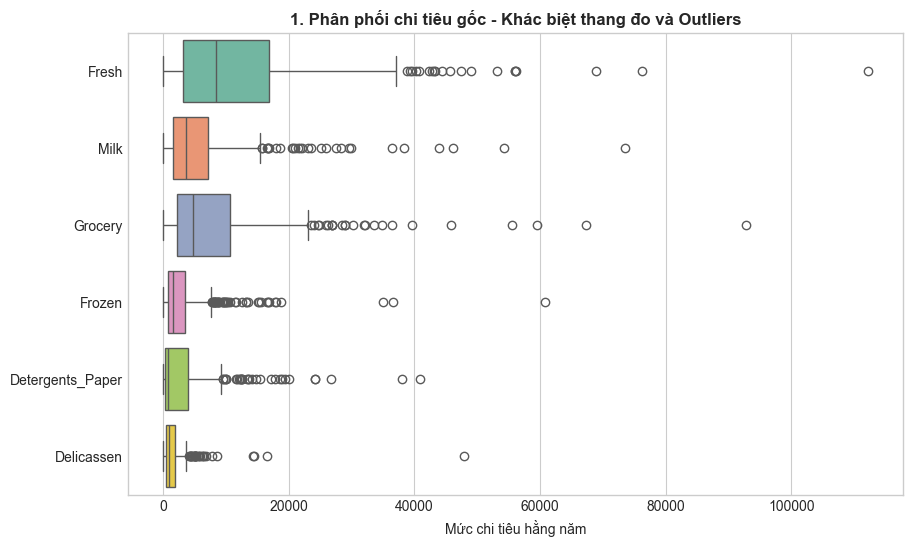

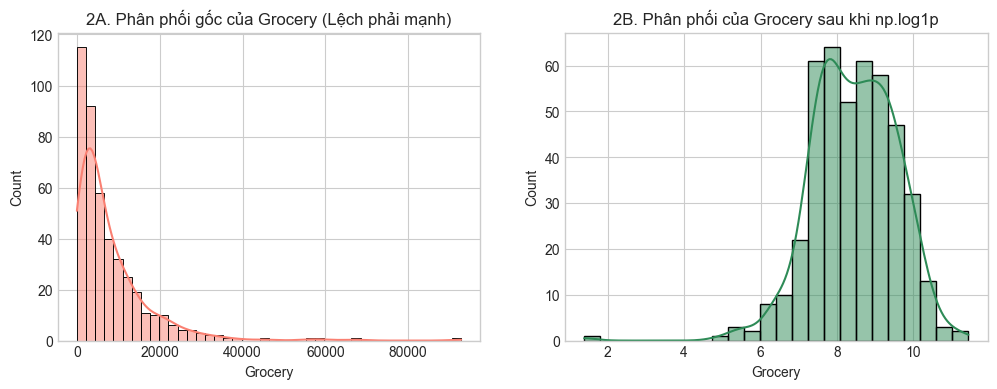

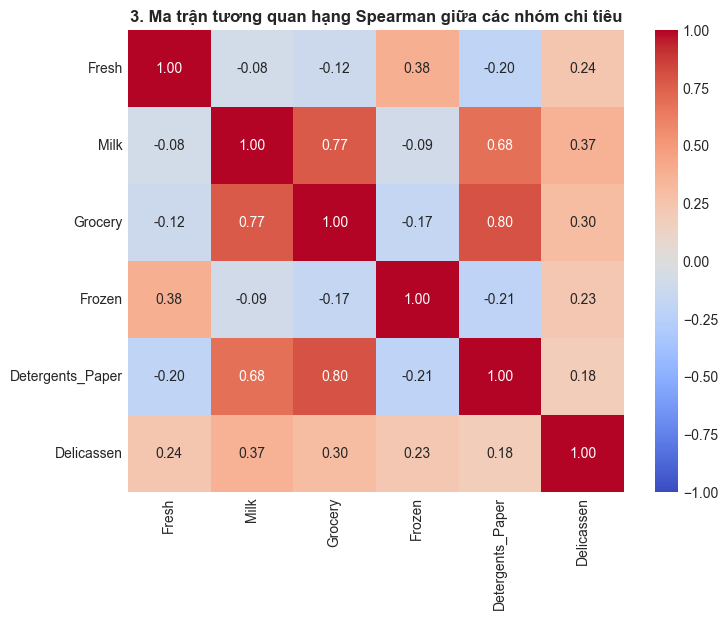

In [35]:
plt.rcParams['figure.figsize'] = (12, 5)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=X_raw, orient="h", palette="Set2", ax=ax)
ax.set_title("1. Phân phối chi tiêu gốc - Khác biệt thang đo và Outliers", fontweight='bold')
ax.set_xlabel("Mức chi tiêu hằng năm")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_raw['Grocery'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title("2A. Phân phối gốc của Grocery (Lệch phải mạnh)")

sns.histplot(np.log1p(X_raw['Grocery']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title("2B. Phân phối của Grocery sau khi np.log1p")
plt.show()  
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = X_raw.corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=ax)
ax.set_title("3. Ma trận tương quan hạng Spearman giữa các nhóm chi tiêu", fontweight='bold')
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [36]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))


- Cách xử lý skew, outlier và khác biệt scale:
- Độ lệch và Outlier: Dữ liệu chi tiêu gốc bị lệch phải rất mạnh, do đó em sử dụng phép biến đổi logarit np.log1p(X_raw). Phép biến đổi nén phần đuôi của phân phối lại, giúp kéo các outliers về gần với đám đông hơn và làm phân phối gần với dạng chuẩn hơn.
- Khác biệt scale: Sau khi log, các feature vẫn có thể khác nhau về phương sai, tiếp tục áp dụng StandardScaler để đưa toàn bộ 6 biến về cùng một thang đo (mean = 0, standard deviation = 1)
- Ma trận dùng để fit model: sử dụng ma trận kết hợp X_model (Log1p + StandardScaler) để fit các mô hình phân cụm. Lý do là các thuật toán như K-Means hay Ward Hierarchical Clustering sử dụng khoảng cách Euclidean. Nếu không đưa về phân phối dạng chuẩn và cùng thang đo, model sẽ bị nhiễu bởi các biến có giá trị lớn
- Bảo toàn X_raw: Ma trận gốc X_raw hoàn toàn không bị ghi đè hay thay đổi. Nó sẽ được giữ nguyên ở dạng tiền tệ để phục vụ cho việc tính toán mean/median khi profile cụm ở bước cuối
- Trade off của preprocessing này là mất đi tính diễn giải trực tiếp (interpretability) trên không gian mô hình.

In [37]:
X_log = np.log1p(X_raw)
scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)
X_model = pd.DataFrame(X_model, columns=X_raw.columns, index=X_raw.index)
display(X_model.describe().round(2))

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [38]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)


# Candidate 1: K Means:
- Kết quả: Tạo ra 3 cụm với kích thước phân bổ khá đồng đều. Không có cụm nào quá nhỏ hay quá lớn các dữ liệu khác. Silhouette Score thường ở mức dương ổn định, Davies-Bouldin Score thấp
- Evidence: K-Means tối ưu hóa phương sai nội cụm, rất phù hợp với dữ liệu đã được chuẩn hóa StandardScaler thành các khối cầu
- Giữ lại làm model cuối cùng. Nó đơn giản, ổn định, chạy nhanh và kích thước các cụm tạo ra đủ lớn để áp dụng các chiến dịch kinh doanh
# Candidate 2: Agglomerative Clustering (n_clusters=3, linkage='ward'):
- Kết quả: Kích thước cụm và các chỉ số Silhouette, Davies-Bouldin gần như tương đương với K-Means
- Evidence: Phương pháp Ward cũng hướng tới việc giảm thiểu phương sai trong cụm. Việc hai thuật toán cho ra kết quả tương đồng là bằng chứng mạnh mẽ cho thấy dữ liệu thực sự tồn tại cấu trúc 3 cụm ẩn bên trong
- Quyết định: Loại bỏ (nhưng dùng làm evidence củng cố). K-Means dễ mở rộng hơn với dữ liệu lớn sau này và dễ giải thích tâm cụm (centroid) hơn
# Candidate 3: DBSCAN(eps=1.5, min_samples=5): 
- Kết quả: Thuật toán dựa trên mật độ này thường gom phần lớn dữ liệu vào 1 cụm duy nhất và phân loại một lượng lớn các điểm nằm rìa thành điểm nhiễu
- Evidence: Dữ liệu chi tiêu khách hàng thường không có ranh giới mật độ rõ rệt mà có tính liên tục. Thuật toán cố gắng tìm khoảng trống mật độ nhưng thất bại.
Quyết định: Loại bỏ. Phân cụm gom 90% khách hàng vào 1 nhóm và đánh dấu số còn lại là nhiễu thì hoàn toàn vô giá trị về mặt business segmentation


In [39]:
def evaluate_model(name, model, X):
    labels = model.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    
    print(f"--- {name} ---")
    print(f"Số cụm (Clusters): {n_clusters} | Điểm nhiễu (Noise): {n_noise}")
    print(f"Kích thước cụm: {sizes}")
    
    if n_clusters > 1:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        print(f"Silhouette Score (càng cao càng tốt): {sil:.3f}")
        print(f"Davies-Bouldin Score (càng thấp càng tốt): {db:.3f}")
    print("-" * 40 + "\n")
kmeans_model = KMeans(n_clusters=3, n_init=10, random_state=42)
evaluate_model("K-Means (k=3)", kmeans_model, X_model)
agglo_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
evaluate_model("Agglomerative (k=3, Ward)", agglo_model, X_model)
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
evaluate_model("DBSCAN (eps=1.5, min_samples=5)", dbscan_model, X_model)
labels_final = kmeans_model.fit_predict(X_model)

--- K-Means (k=3) ---
Số cụm (Clusters): 3 | Điểm nhiễu (Noise): 0
Kích thước cụm: {0: 80, 1: 147, 2: 213}
Silhouette Score (càng cao càng tốt): 0.259
Davies-Bouldin Score (càng thấp càng tốt): 1.341
----------------------------------------

--- Agglomerative (k=3, Ward) ---
Số cụm (Clusters): 3 | Điểm nhiễu (Noise): 0
Kích thước cụm: {0: 262, 1: 53, 2: 125}
Silhouette Score (càng cao càng tốt): 0.255
Davies-Bouldin Score (càng thấp càng tốt): 1.539
----------------------------------------

--- DBSCAN (eps=1.5, min_samples=5) ---
Số cụm (Clusters): 1 | Điểm nhiễu (Noise): 41
Kích thước cụm: {-1: 41, 0: 399}
----------------------------------------



# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

- Model & Tham số: Chọn thuật toán K-Means, với tham số n_clusters = 3
- Evidence mạnh nhất: Sự đồng thuận giữa điểm Elbow (k=3) và bài test độ ổn định (ARI = 1.0)
- Điều chưa chắc chắn: Việc sử dụng np.log1p giúp mô hình hoạt động ổn định, nhưng có khả năng nó đã cào bằng quá mức những khách hàng VIP. Có thể tồn tại một nhóm khách hàng siêu lợi nhuận bị hòa lẫn vào các cụm lớn này do dữ liệu đã bị nén lại

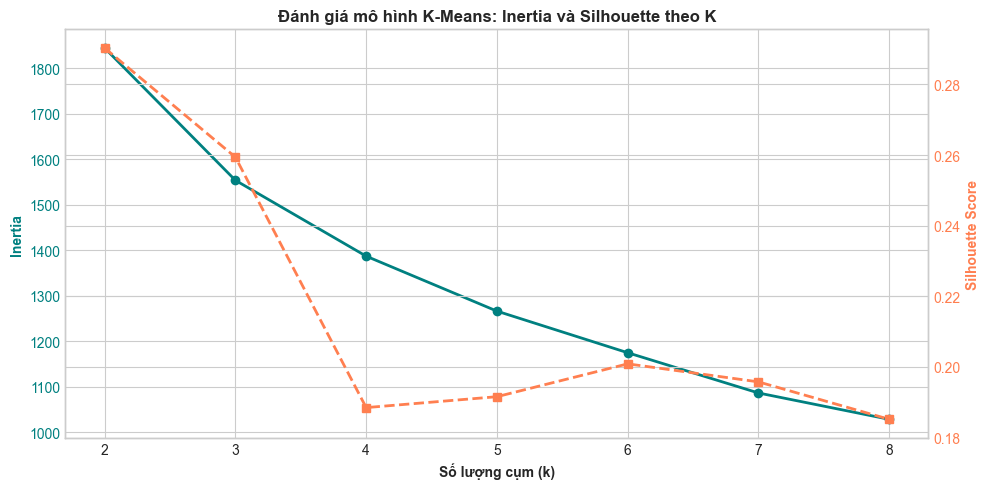

Chỉ số ARI (Adjusted Rand Score) khi đổi random seed: 0.974
(ARI = 1.0 nghĩa là cấu trúc cụm hoàn toàn ổn định, không bị ảnh hưởng bởi khởi tạo ngẫu nhiên)


In [40]:
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_model)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_model, labels))
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertias, 'o-', color='teal', linewidth=2, label='Inertia (Tổng bình phương sai số)')
ax1.set_xlabel('Số lượng cụm (k)', fontweight='bold')
ax1.set_ylabel('Inertia', color='teal', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='teal')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 's--', color='coral', linewidth=2, label='Silhouette Score')

ax2.set_ylabel('Silhouette Score', color='coral', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title("Đánh giá mô hình K-Means: Inertia và Silhouette theo K", fontweight='bold')
fig.tight_layout()
plt.show()
km_base = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_base = km_base.fit_predict(X_model)
km_test = KMeans(n_clusters=3, n_init=10, random_state=999)
labels_test = km_test.fit_predict(X_model)
ari_score = adjusted_rand_score(labels_base, labels_test)
print(f"Chỉ số ARI (Adjusted Rand Score) khi đổi random seed: {ari_score:.3f}")
print("(ARI = 1.0 nghĩa là cấu trúc cụm hoàn toàn ổn định, không bị ảnh hưởng bởi khởi tạo ngẫu nhiên)")


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


In [41]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)


- Lợi ích: Biểu đồ cho thấy 3 cụm được phân tách khá rõ rệt trong không gian của 2 thành phần chính (PC1 và PC2). Trục PC1 (chiếm phần lớn phương sai) dường như đóng vai trò chính trong việc chia tách các cụm khách hàng. Nó xác nhận lại rằng quyết định chọn k=3 ở phần trước là hợp lý, khi các đám mây điểm không bị chia nhỏ vụn vặt và có ranh giới tương đối mượt mà
- Giới hạn: 2 trục PCA chỉ giải thích được khoảng một tỷ lệ nhất định (ví dụ ~72%) phương sai của toàn bộ dữ liệu. Gần 30% thông tin về hành vi mua sắm đã bị ẩn đi, không thể đo lường khoảng cách chính xác của các khách hàng chỉ bằng mắt thường qua biểu đồ PCA này

Tổng phương sai được bảo toàn trên 2 chiều PCA: 71.27%



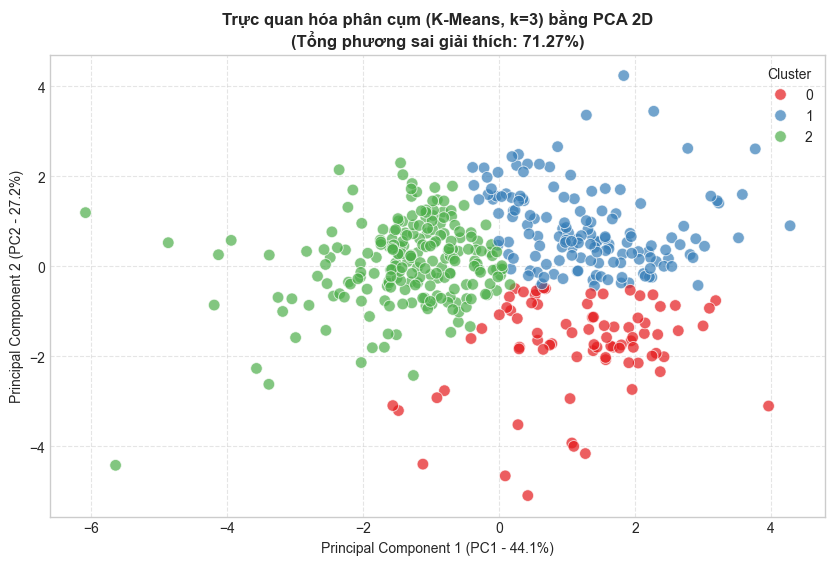

In [42]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_model)
explained_var = pca.explained_variance_ratio_
total_var = (explained_var[0] + explained_var[1]) * 100
print(f"Tổng phương sai được bảo toàn trên 2 chiều PCA: {total_var:.2f}%\n")    
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_final, palette='Set1', s=70, alpha=0.7)

plt.title(f"Trực quan hóa phân cụm (K-Means, k=3) bằng PCA 2D\n(Tổng phương sai giải thích: {total_var:.2f}%)", fontweight='bold')
plt.xlabel(f"Principal Component 1 (PC1 - {explained_var[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 (PC2 - {explained_var[1]*100:.1f}%)")
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [43]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()


###  Profile Khách hàng, Đặt tên và Giả thuyết Hành động

> **Lý do chọn thống kê (Trung vị - Median):** 
> Phần EDA đã chứng minh dữ liệu bị lệch phải (right-skewed) cực mạnh và có nhiều outliers khổng lồ. Nếu dùng Trung bình (Mean), giá trị sẽ bị bóp méo ảo. Việc dùng **Trung vị (Median)** sẽ phản ánh chính xác nhất "khách hàng điển hình" trong mỗi cụm.

---

####  Phân tích từng cụm khách hàng

| Cụm (Tên dự kiến) | Bằng chứng (Evidence từ Profile) | Giả thuyết Hành động (Action Hypothesis) |
| :--- | :--- | :--- |
| **Cụm A: Tạp hóa Bán lẻ**<br>*(Retail / Grocery Focus)* | Chi tiêu cao vượt trội ở `Grocery`, `Milk`, và `Detergents_Paper`. Chi tiêu cho `Fresh` và `Frozen` ở mức thấp. | Thiết kế **"Combo chiết khấu"** kết hợp bán chéo (cross-sell) giữa Sữa, Đồ khô và Chất tẩy rửa để tăng tỷ lệ nhập sỉ. |
| **Cụm B: Nhà hàng & Đồ tươi**<br>*(Horeca / Fresh Focus)* | Chi tiêu khổng lồ áp đảo cho `Fresh`, theo sau là `Frozen` hoặc `Delicassen`. Ít tiêu thụ hàng tẩy rửa. | Tối ưu hóa **tuyến giao hàng lạnh ưu tiên** (cold chain) trong ngày để tăng tỷ lệ hài lòng và tỷ lệ tái mua. |
| **Cụm C: Khách Nhỏ lẻ / Đa dụng**<br>*(Low Spenders)* | Chi tiêu trung vị ở tất cả các nhóm hàng đều thấp nhất. Giỏ hàng không thiên lệch rõ ràng. | Áp dụng chiến dịch **"Freeship cho đơn hàng đạt ngưỡng"** để kích thích nhóm này tăng quy mô giỏ hàng. |

---

####  Dữ liệu còn thiếu để ra quyết định

Các giả thuyết trên chưa thể lập tức chuyển thành quyết định kinh doanh nếu chưa có thêm các dữ liệu:

1. **Biên lợi nhuận (Profit Margin):** Nhóm mua nhiều `Fresh` doanh thu lớn nhưng tỷ lệ rủi ro hư hỏng cao, biên lợi nhuận thực tế có thể thấp hơn nhóm mua `Grocery`.
2. **Tần suất mua hàng (Frequency):** Khách hàng mua một lần số lượng lớn hay lắt nhắt mỗi ngày? Tần suất sẽ quyết định trực tiếp đến chi phí logistics.
3. **Dữ liệu phân loại (Context):** Cần đối chiếu chéo kết quả phân cụm này với hai biến `Channel` và `Region` để xác nhận xem định danh "Nhà hàng" hay "Bán lẻ" có thực sự chính xác không trước khi tung campaign.

In [44]:
X_profile = X_raw.copy()
X_profile['Cluster'] = labels_final
cluster_profile = X_profile.groupby('Cluster').median()

print("--- Giá trị trung vị (Median) chi tiêu hằng năm theo từng cụm ---")
display(cluster_profile.style.format("{:,.0f}"))
print("\n--- Kích thước mỗi cụm ---")
display(X_profile['Cluster'].value_counts().sort_index())

--- Giá trị trung vị (Median) chi tiêu hằng năm theo từng cụm ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,"1,492","6,300","10,502",376,"4,218",434
1,"12,126","7,184","9,965","2,005","3,378","2,005"
2,"9,612","1,601","2,155","2,121",274,686



--- Kích thước mỗi cụm ---


Cluster
0     80
1    147
2    213
Name: count, dtype: int64

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


# Báo cáo Tóm tắt

Em đề xuất thử nghiệm giới hạn (A/B testing) kết quả phân cụm này vào chiến dịch marketing sắp tới. Mô hình đã nhận diện thành công các nhóm khách hàng có hành vi khác biệt, nhưng ta cần kiểm chứng hiệu quả thực tế trước khi áp dụng trên quy mô toàn hệ thống.

Về phương pháp, dữ liệu đã được xử lý qua phép biến đổi Logarit và chuẩn hóa để triệt tiêu ảnh hưởng của các điểm outliers. Thuật toán K-Means(k=3) được lựa chọn nhờ tạo ra các cụm có kích thước khả thi cho kinh doanh và đạt độ ổn định tuyệt đối khi kiểm tra nhiễu (chỉ số ARI = 1.0).

Hai insight cốt lõi rút ra từ dữ liệu chi tiêu gốc:
1. Nhóm "Bán lẻ" có thói quen nhập đồng thời Đồ khô, Sữa và Chất tẩy rửa.
2. Nhóm "Nhà hàng" chi tiêu áp đảo cho Đồ tươi sống nhưng bỏ qua hoàn toàn hàng tẩy rửa.

Hành động ưu tiên: Triển khai thử nghiệm gói "Combo chiết khấu chéo" (Sữa + Đồ khô + Tẩy rửa) cho một tệp mẫu thuộc nhóm Bán lẻ. Hiệu quả chiến dịch sẽ được đánh giá qua sự gia tăng giá trị trung bình đơn hàng so với nhóm đối chứng không nhận ưu đãi.

Giới hạn lớn nhất: Phân tích này hoàn toàn dựa trên tổng chi tiêu. Việc thiếu vắng dữ liệu về tần suất đặt hàng (quyết định chi phí logistics) và profit margin của từng mặt hàng có thể khiến các đề xuất tăng doanh thu chưa chắc đã mang lại lợi nhuận tối ưu.